## Step 1: Import libraries

In [3]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from transformers import BertTokenizer
from transformers.models.bert.modeling_tf_bert import TFBertForSequenceClassification
from tensorflow.keras.callbacks import EarlyStopping

os.environ["TF_USE_LEGACY_KERAS"] = "1"

## Step 2: Load dataset

In [73]:
data = pd.read_csv("symptoms based medical test recommendations.csv")
data = data[["Questions", "medical tests", "predicted disease"]].dropna().drop_duplicates().reset_index(drop=True)
data

,Questions,medical tests,predicted disease
0,"I have a fever, cough, body aches, headache, a...","Complete Blood Count (CBC),C-Reactive Protein ...",Influenza (Flu)
1,"My symptoms include a sore throat, runny nose,...","Complete Blood Count (CBC),C-Reactive Protein ...",Influenza (Flu)
2,"I'm experiencing chest congestion, shortness o...","Complete Blood Count (CBC),C-Reactive Protein ...",Influenza (Flu)
3,"I have a high fever, nausea, and vomiting. Whi...","Complete Blood Count (CBC),C-Reactive Protein ...",Influenza (Flu)
4,"My symptoms involve a persistent cough, fatigu...","Complete Blood Count (CBC),C-Reactive Protein ...",Influenza (Flu)
...,...,...,...
1461,Is it common for salt cravings and nausea to b...,"Cortisol Levels,Adrenocorticotropic Hormone (A...",Addison's Disease
1462,I have salt and water imbalance and fatigue. W...,"Cortisol Levels,Adrenocorticotropic Hormone (A...",Addison's Disease
1463,Could weight loss and joint pain be linked to ...,"Cortisol Levels,Adrenocorticotropic Hormone (A...",Addison's Disease
1464,I'm struggling with loss of appetite and darke...,"Cortisol Levels,Adrenocorticotropic Hormone (A...",Addison's Disease


## Step 3: Dataset overview

In [9]:
print("Shape:", data.shape)
display(data.info())
display(data.describe(include="all"))

Shape: (1466, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1466 entries, 0 to 1465
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Questions          1466 non-null   object
 1   medical tests      1466 non-null   object
 2   predicted disease  1466 non-null   object
dtypes: object(3)
memory usage: 34.5+ KB


None

,Questions,medical tests,predicted disease
count,1466,1466,1466
unique,1466,29,30
top,"I have a fever, cough, body aches, headache, a...","Thyroid-Stimulating Hormone (TSH) Test,Free T4...",Influenza (Flu)
freq,1,100,50


## Step 4: Missing values and duplicates

In [12]:
print("Missing values:\n", data.isnull().sum())
print("\nDuplicate rows:", data.duplicated().sum())
print("\nUnique diseases:", data["predicted disease"].nunique())
print("Unique medical tests:", data["medical tests"].nunique())
print("Unique questions:", data["Questions"].nunique())

Missing values:
 Questions            0
medical tests        0
predicted disease    0
dtype: int64

Duplicate rows: 0

Unique diseases: 30
Unique medical tests: 29
Unique questions: 1466


## Step 5: EDA  Exploratory Data Analysis


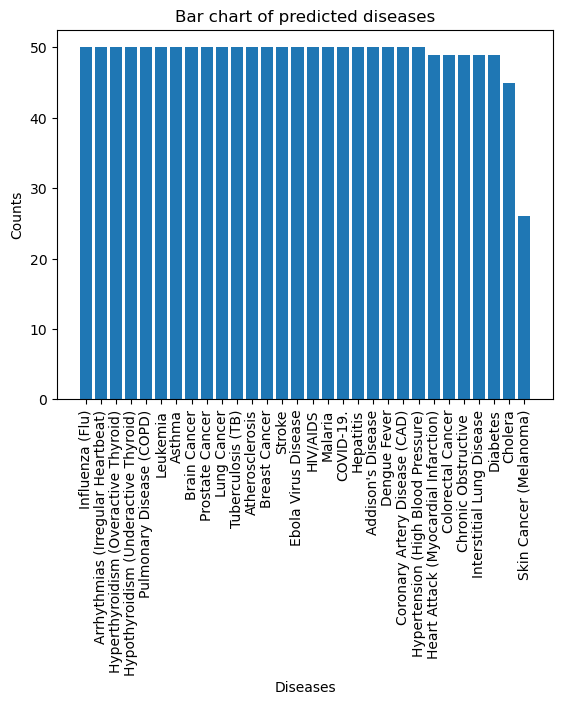

In [59]:
unique_counts = data['predicted disease'].value_counts()
plt.bar(unique_counts.index, unique_counts)


plt.xlabel('Diseases')
plt.ylabel('Counts')
plt.title('Bar chart of predicted diseases')


plt.xticks(rotation=90)

plt.show()

## Step 6: Encode labels


In [20]:
label_encoder = LabelEncoder()
data["encoded_labels"] = label_encoder.fit_transform(data["predicted disease"])
data[["predicted disease", "encoded_labels"]]

,predicted disease,encoded_labels
0,Influenza (Flu),20
1,Influenza (Flu),20
2,Influenza (Flu),20
3,Influenza (Flu),20
4,Influenza (Flu),20
...,...,...
1461,Addison's Disease,0
1462,Addison's Disease,0
1463,Addison's Disease,0
1464,Addison's Disease,0


## Step 7: Load tokenizer

In [24]:
tokenizer = BertTokenizer.from_pretrained("bert-base-cased")

C:\Users\HP\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


## Step 8: Tokenize text


In [27]:
MAX_LEN = 256
input_ids = []
attention_masks = []

for text in data["Questions"].astype(str):
    token = tokenizer.encode_plus(
        text,
        max_length=MAX_LEN,
        truncation=True,
        padding="max_length",
        add_special_tokens=True
    )
    input_ids.append(token["input_ids"])
    attention_masks.append(token["attention_mask"])

input_ids = np.array(input_ids)
attention_masks = np.array(attention_masks)
labels = data["encoded_labels"].values

input_ids.shape, attention_masks.shape

((1466, 256), (1466, 256))

## Step 9: Train-test split

In [30]:
X_train_ids, X_test_ids, X_train_mask, X_test_mask, y_train, y_test = train_test_split(
    input_ids, attention_masks, labels, test_size=0.2, random_state=42, stratify=labels
)

## Step 10: Create datasets


In [33]:
BATCH_SIZE = 16

train_dataset = tf.data.Dataset.from_tensor_slices(
    ({"input_ids": X_train_ids, "attention_mask": X_train_mask}, y_train)
).shuffle(1000).batch(BATCH_SIZE)

test_dataset = tf.data.Dataset.from_tensor_slices(
    ({"input_ids": X_test_ids, "attention_mask": X_test_mask}, y_test)
).batch(BATCH_SIZE)

## Step 11: Build model

In [36]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tf_keras as keras
from transformers.models.bert.modeling_tf_bert import TFBertForSequenceClassification

model = TFBertForSequenceClassification.from_pretrained(
    "bert-base-cased",
    num_labels=len(label_encoder.classes_)
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

C:\Users\HP\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Step 12: Train model

In [39]:
import tf_keras as keras

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5


74/74 [==============================] - 1884s 25s/step - loss: 3.1740 - accuracy: 0.1706 - val_loss: 2.6845 - val_accuracy: 0.4592
Epoch 2/5
74/74 [==============================] - 1901s 26s/step - loss: 2.2703 - accuracy: 0.6195 - val_loss: 1.7174 - val_accuracy: 0.7721
Epoch 3/5
74/74 [==============================] - 1680s 23s/step - loss: 1.5160 - accuracy: 0.7952 - val_loss: 1.0880 - val_accuracy: 0.8537
Epoch 4/5
74/74 [==============================] - 1879s 25s/step - loss: 0.9797 - accuracy: 0.8669 - val_loss: 0.7233 - val_accuracy: 0.8844
Epoch 5/5
74/74 [==============================] - 1900s 26s/step - loss: 0.6712 - accuracy: 0.9027 - val_loss: 0.5063 - val_accuracy: 0.9252


## Step 13: Save model


In [61]:
model.save("medicaltestsmodel.keras")

C:\Users\HP\anaconda3\Lib\site-packages\transformers\generation\tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


## Step 14: Evaluation metrics


In [63]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

y_prob = model.predict(test_dataset).logits
y_pred = np.argmax(y_prob, axis=1)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

19/19 [==============================] - 115s 6s/step - loss: 0.5063 - accuracy: 0.9252
Test Loss: 0.5063280463218689
Test Accuracy: 0.9251700639724731
19/19 [==============================] - 122s 6s/step
Accuracy Score: 0.9251700680272109

Classification Report:

                                      precision    recall  f1-score   support

                   Addison's Disease       0.90      0.90      0.90        10
   Arrhythmias (Irregular Heartbeat)       1.00      1.00      1.00        10
                              Asthma       1.00      1.00      1.00        10
                     Atherosclerosis       1.00      1.00      1.00        10
                        Brain Cancer       1.00      1.00      1.00        10
                       Breast Cancer       1.00      1.00      1.00        10
                           COVID-19.       1.00      1.00      1.00        10
                             Cholera       1.00      0.89      0.94         9
                Chronic Obstruc

## Step 15: Confusion matrix


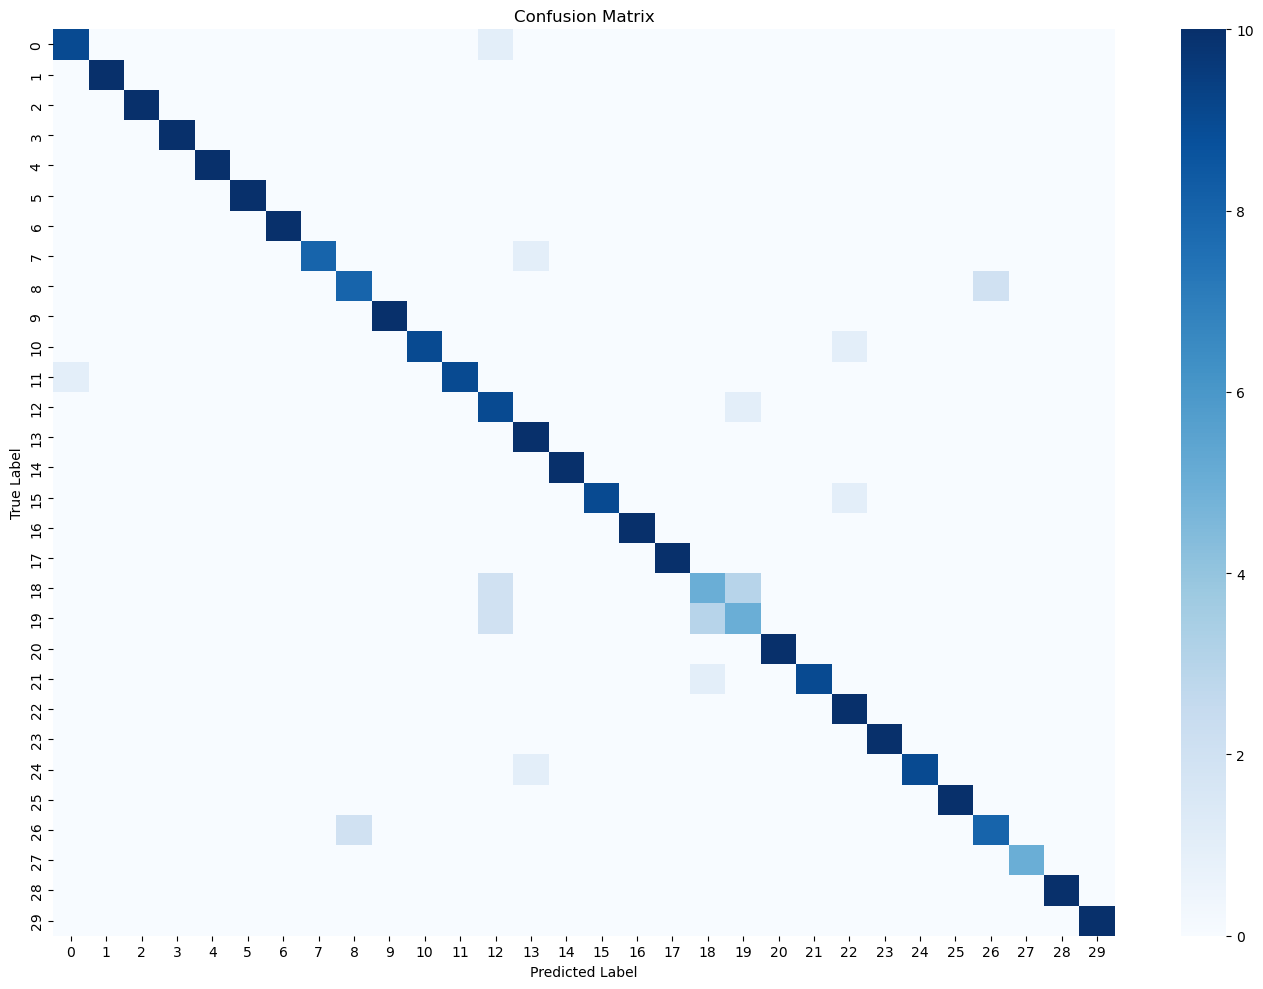

In [64]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, cmap="Blues", annot=False, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## Step 16: Training curves


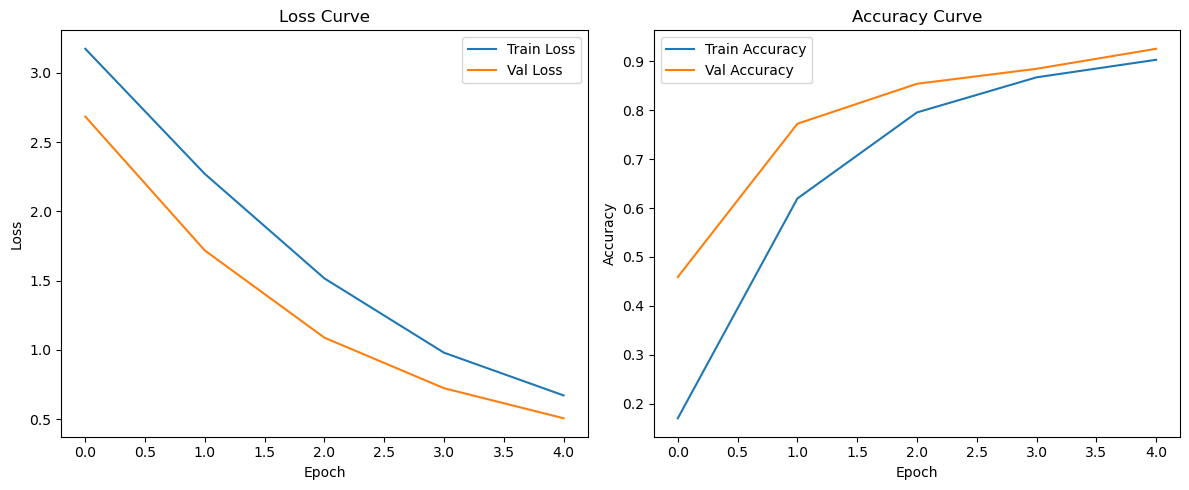

In [65]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Step 17: Prediction function


In [66]:
def predict_disease(text):
    token = tokenizer.encode_plus(
        text,
        max_length=MAX_LEN,
        truncation=True,
        padding="max_length",
        add_special_tokens=True,
        return_tensors="tf"
    )

    inputs = {
        "input_ids": tf.cast(token["input_ids"], tf.int32),
        "attention_mask": tf.cast(token["attention_mask"], tf.int32)
    }

    outputs = model(inputs, training=False)
    probs = tf.nn.softmax(outputs.logits, axis=-1).numpy()[0]
    pred_idx = int(np.argmax(probs))
    return label_encoder.inverse_transform([pred_idx])[0]

## Step 18: Test prediction


In [77]:
medical_tests_map = {
    "Influenza (Flu)": "Complete Blood Count (CBC), C-Reactive Protein (CRP), Procalcitonin, Influenza Antibody Testing",
    "Tuberculosis (TB)": "Tuberculin Skin Test (TST) or Mantoux Test, Interferon-Gamma Release Assays (IGRAs), CBC, ESR, CRP",
    "HIV/AIDS": "HIV Antibody Test (ELISA/Western Blot), CD4 Count, Viral Load Test, Resistance Testing",
    "Malaria": "Malaria Smear Blood Film, Rapid Diagnostic Tests (RDT), PCR, QBC Test, Serology Tests",
    "COVID-19": "Antigen Tests, Antibody Serology Tests, CRP, D-Dimer, CBC, Ferritin Test"
}

text = input("Enter your symptoms: ")
disease = predict_disease(text)
tests = medical_tests_map.get(disease, "No test mapping found for this disease")

print("Predicted disease:", disease)
print("Recommended medical tests:", tests)

Enter your symptoms:  my symptoms include a sore throat runny nose headache


Predicted disease: Influenza (Flu)
Recommended medical tests: Complete Blood Count (CBC), C-Reactive Protein (CRP), Procalcitonin, Influenza Antibody Testing
